# Transforms and Data Augmentation

Motion capture datasets are often small — recording sessions are expensive and time-consuming. **Data augmentation** artificially increases the effective size of a dataset by applying plausible transformations to existing clips. **Preprocessing** is the sibling concept: deterministic transformations applied once to normalize data before training.

This tutorial covers both. `pybvh.transforms` provides spatial transforms that fall into three families:

| Family | Purpose | Examples |
|---|---|---|
| **Deterministic augmentation** | Expand a dataset in a predictable way | `mirror`, `rotate_vertical`, `translate_root` |
| **Stochastic augmentation** | Randomized variants for online training | `random_rotate_vertical`, `add_noise`, `drop_frames` |
| **Preprocessing / normalization** | Bring heterogeneous files into a common frame | `reorient_world_up`, `reorient_rest_up`, `reorient_rest_forward` |

We cover each in turn, then look at how to compose them.

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

import pybvh
from pybvh import transforms
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
bvh_folder = REPO_ROOT / "bvh_data"
bvh = pybvh.read_bvh_file(bvh_folder / 'bvh_test1.bvh')
print(bvh)

24 joints, 75 frames at 30.0 fps (frame_time=0.033333s, from bvh_test1.bvh)


# The API pattern

Every transform in `pybvh.transforms` is also available as a method on the `Bvh` object. The two forms call the same code:

```python
bvh.mirror()                      # method style (used throughout this tutorial)
transforms.mirror(bvh)            # module style (same result)
```

The module form is useful when you want to apply a transform from code that doesn't already hold a `Bvh` reference, or when building pipelines as lists of functions.

All mutating transforms follow the `inplace=False` convention: by default they return a **new** `Bvh` object and leave the original unchanged. This is why you can chain calls without worrying about side effects. We'll come back to the `inplace=True` option in the *Composing transforms* section.

# Mirroring

**Mirroring** flips a motion left-to-right — a person walking and swinging their right arm becomes a person walking and swinging their left arm. It's one of the most common augmentations for human motion data because bilateral symmetry is (approximately) a property of human bodies.

Mirroring is *not* just negating an axis. Consider what a naive axis flip does: every joint's X coordinate (say) gets negated. The left knee ends up where the right knee was — but it's still labelled "LeftKnee" and still bends inward relative to its original side. The result is anatomically impossible: a leg whose knee bends outward.

Correct mirroring requires two steps:

1. **Flip the lateral axis.** The **lateral axis** is the axis perpendicular to the mirror plane — roughly shoulder-to-shoulder for a standing character. Flipping it is the geometric mirror operation.
2. **Swap paired joints.** Every joint whose name starts with `Left*` exchanges data with its `Right*` counterpart, and vice versa.

pybvh's `mirror()` does both.

## Auto-detecting left/right pairs

pybvh auto-detects L/R joint pairs at load time from joint names; `mirror()` reads that mapping when it runs. You can inspect it before applying the transform — useful for sanity-checking on unusual skeletons.

In [2]:
mapping = bvh.lr_mapping

print(f'Detected {len(mapping)} L/R joint pairs:')
for left, right in mapping.items():
    print(f'  {left:20s} <-> {right}')

Detected 16 L/R joint pairs:
  LeftShoulder         <-> RightShoulder
  RightShoulder        <-> LeftShoulder
  LeftArm              <-> RightArm
  RightArm             <-> LeftArm
  LeftForeArm          <-> RightForeArm
  RightForeArm         <-> LeftForeArm
  LeftHand             <-> RightHand
  RightHand            <-> LeftHand
  LeftUpLeg            <-> RightUpLeg
  RightUpLeg           <-> LeftUpLeg
  LeftLeg              <-> RightLeg
  RightLeg             <-> LeftLeg
  LeftFoot             <-> RightFoot
  RightFoot            <-> LeftFoot
  LeftToeBase          <-> RightToeBase
  RightToeBase         <-> LeftToeBase


`bvh.lr_mapping` was introduced in Tutorial 1 — the auto-detected dict of L/R joint names. `mirror()` reads it to know which joints to swap. For tensor pipelines that need `(left_idx, right_idx)` index tuples instead of names, `transforms.auto_detect_lr_pairs(bvh)` returns that form.

## Applying the mirror

With pairs detected, `mirror()` handles the flip and the swap in one call. The lateral axis is auto-detected from the skeleton topology (you can override it with `lateral_axis='x'` / `'y'` / `'z'` if needed).

In [3]:
mirrored = bvh.mirror()

fig, axes = pybvh.bvhplot.frame([bvh, mirrored], frame=30,
                                 labels=['Original', 'Mirrored'])
plt.show()

/tmp/ipykernel_2424241/1836295587.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Visually, the skeletons look like reflections — left and right are swapped. To confirm the swap numerically, compare `LeftArm` angles in the original with `RightArm` angles in the mirrored clip: the magnitudes should match, with selective sign flips on the Euler channels whose axes are *not* the lateral axis (those axes have their direction reversed under the mirror).

In [4]:
# joint_index is the right lookup for joint_angles (see Tutorial 2).
left_idx = bvh.joint_index['LeftArm']
right_idx = bvh.joint_index['RightArm']

print('LeftArm rotation channel order:', bvh.nodes[bvh.node_index["LeftArm"]].rot_channels)
print('Original  LeftArm  angles (frame 0):', bvh.joint_angles[0, left_idx])
print('Mirrored  RightArm angles (frame 0):', mirrored.joint_angles[0, right_idx])

LeftArm rotation channel order: ['X', 'Z', 'Y']
Original  LeftArm  angles (frame 0): [ 0.1659 -0.0331 -0.7808]
Mirrored  RightArm angles (frame 0): [0.1659 0.0331 0.7808]


# Vertical (yaw) rotation

**Vertical rotation** rotates the entire motion around the up axis — i.e., it changes the character's facing direction (yaw). It's also called **yaw-only augmentation** in the ML literature.

Why only the up axis? A character's motion is physically coupled to gravity — the feet touch a horizontal ground plane. Rotating around any non-vertical axis tilts the character relative to that ground plane: feet float, body leans, the recorded motion becomes nonsensical. Vertical rotation is the one rotation that preserves ground contact and the intuitive meaning of "up".

The up axis is auto-detected from the skeleton (`bvh.world_up`) — no need to specify it manually in most cases. The angle is in **radians**, the same convention as `bvh.joint_angles`; pass `degrees=True` if you prefer to think in degrees.

In [5]:
rotated = bvh.rotate_vertical(np.pi / 2)          # same as bvh.rotate_vertical(90, degrees=True)

fig, axes = pybvh.bvhplot.frame([bvh, rotated], frame=20,
                                 labels=['Original', 'Rotated 90°'],
                                 camera=(120,20))
plt.show()

/tmp/ipykernel_2424241/453442397.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The pose is unchanged — only the character's facing direction differs. The root trajectory rotates by the same 90° around the origin:

In [6]:
fig, ax = pybvh.bvhplot.trajectory([bvh, rotated], labels=['Original', 'Rotated 90°'])
plt.show()

/tmp/ipykernel_2424241/1257642283.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Random yaw

For augmentation, a random angle is typical. `random_rotate_vertical()` samples uniformly from `angle_range` (default `(-π, π)` — i.e., any facing direction is equally likely; pass `degrees=True` to give the range in degrees).

In [7]:
rand_rotated = bvh.random_rotate_vertical(rng=np.random.default_rng(42))

fig, axes = pybvh.bvhplot.frame([bvh, rand_rotated], frame=20,
                                 labels=['Original', 'Random yaw (seed=42)'])
plt.show()

/tmp/ipykernel_2424241/3706719934.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Root translation

`translate_root()` shifts the entire motion by a constant 3D offset. The skeleton's pose and relative motion are unchanged — only the world position differs. Useful for moving a clip to a specific starting location, or for augmenting spatial position when world coordinates matter.

In [8]:
translated = bvh.translate_root(offset=[50, 0, 0])

fig, ax = pybvh.bvhplot.trajectory([bvh, translated],
                                    labels=['Original', 'Translated +50 X'])
plt.show()

print(f'Original   root position (frame 0): {bvh.root_pos[0]}')
print(f'Translated root position (frame 0): {translated.root_pos[0]}')

Original   root position (frame 0): [ -0.8231 -10.8992  36.4219]
Translated root position (frame 0): [ 49.1769 -10.8992  36.4219]


/tmp/ipykernel_2424241/4194189822.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The random variant, `random_translate_root()`, samples each axis uniformly from a given range:

In [9]:
rand_translated = bvh.random_translate_root(offset_range=(-50, 50),
                                            rng=np.random.default_rng(42))

print(f'Random offset applied (frame 0): {rand_translated.root_pos[0] - bvh.root_pos[0]}')

Random offset applied (frame 0): [27.3956 -6.1122 35.8598]


# Reorientation

Reorientation is a **preprocessing** operation — it normalizes the coordinate system of BVH files without changing what the character looks like. Use it when mixing files from different sources: some 3D tools export Y-up BVH, others Z-up, others face +Y by convention, others face -Z. 

Three variants handle three distinct situations:

| Function | What it changes | What stays the same |
|---|---|---|
| `reorient_world_up(new_up)` | Whole scene rotates; root positions, rest offsets, and joint angles all rewritten in the new frame | Character appearance and motion |
| `reorient_rest_up(new_up)` | Rest-pose offsets + joint angles (compensating; fixes rest/animation disagreement) | 3D joint positions at every frame |
| `reorient_rest_forward(new_forward)` | Rest-pose offsets + joint angles (compensating; canonical facing) | 3D joint positions at every frame |

We'll demonstrate each.

## `reorient_world_up` — unify up-axis conventions

`bvh_test2.bvh` is a **Y-up** file; our reference `bvh_test1.bvh` is **Z-up**. Side-by-side rendering of two such files looks wrong because one character stands up while the other lies down. `reorient_world_up` fixes this by rotating the entire scene so the up axes match.

In [10]:
bvh_yup = pybvh.read_bvh_file(bvh_folder / 'bvh_test2.bvh')
print(f'bvh (bvh_test1)     world_up: {bvh.world_up}')
print(f'bvh_yup (bvh_test2) world_up: {bvh_yup.world_up}')

# Unify: rotate bvh_yup into +z-up to match bvh
bvh_unified = bvh_yup.reorient_world_up('+z')
print(f'\nAfter reorient, bvh_unified world_up: {bvh_unified.world_up}')

bvh (bvh_test1)     world_up: +z
bvh_yup (bvh_test2) world_up: +y

After reorient, bvh_unified world_up: +z


In [11]:
fig, axes = pybvh.bvhplot.frame([bvh_yup, bvh_unified], frame=0,
                                 labels=['Y-up (original)', 'Z-up (reoriented)'])
plt.show()

/tmp/ipykernel_2424241/1042709975.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Note that the character's pose is identical — only the axis labels move. This is the defining property of `reorient_world_up`: visual appearance unchanged, coordinates rewritten.

## `reorient_rest_up` — fix rest-pose / animation disagreement

Some BVH files have a rest pose authored in one convention but animation data in another — e.g., the rest pose is a Y-up T-pose but the first frame's head-to-hips vector is closer to +Z. pybvh warns on load and picks the animation's convention, but the mismatch lingers in the rest pose itself. See the following example.

In [12]:
# bvh_test3 is the canonical example (per CONTEXT.md): rest pose suggests +y,
# animation plays in +z. pybvh warns on load.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('always')
    bvh_mixed = pybvh.read_bvh_file(bvh_folder / 'bvh_test3.bvh')

fig, ax = bvh_mixed.plot_rest_pose()
ax.set_title("Rest pose, up as '+y'")
plt.show()

fig, ax = bvh_mixed.plot_frame(0)
ax.set_title("Rest pose, up as '+z'")
plt.show()

/home/victor/projects/pybvh/pybvh/bvh.py:162: UserWarning: Rest pose suggests world up is '+y' but the first animation frame's head-hips direction is closer to '+z'. Using '+z' from the animation data. If this is wrong for your file, set it explicitly via `bvh.world_up = '<axis>'`.
  self._world_up_cached = _infer_world_up(self, warn=warn_on_disagreement)
/tmp/ipykernel_2424241/2022457224.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_2424241/2022457224.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


`reorient_rest_up` rotates the rest-pose offsets and compensates all joint rotations so forward kinematics produces **identical** joint positions. The animation looks the same; only the skeleton's rest pose (T-pose) gets fixed.

In [13]:
bvh_fixed = bvh_mixed.reorient_rest_up('+z')

# Joint positions are unchanged by reorient_rest_up — confirm numerically
coords_before = bvh_mixed.node_positions()
coords_after  = bvh_fixed.node_positions()
print(f'Max joint-position difference after reorient_rest_up: {np.abs(coords_before - coords_after).max():.2e}')

fig, ax = bvh_fixed.plot_rest_pose()
ax.set_title("Fixed rest pose, up as '+z'")
plt.show()

Max joint-position difference after reorient_rest_up: 2.13e-14


/tmp/ipykernel_2424241/4276245376.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## `reorient_rest_forward` — canonicalize facing direction

Similar to `reorient_rest_up`, but for the horizontal axis: rotates around the up axis so the skeleton's default forward direction matches `new_forward`. Useful for datasets where some files face `+y` and others `-z`. Again, 3D joint positions are preserved — only the rest pose and joint rotations change in compensation.

In [14]:
bvh_canon_fwd = bvh.reorient_rest_forward('+y')

coords_before = bvh.node_positions()
coords_after  = bvh_canon_fwd.node_positions()
print(f'Max joint-position difference after reorient_rest_forward: {np.abs(coords_before - coords_after).max():.2e}')

Max joint-position difference after reorient_rest_forward: 0.00e+00


For full details on `world_up`, `forward_at`, and the reorientation family, see the [World Up guide](https://victors-67.github.io/pybvh/guide/world-up/).

# Joint noise

`add_noise()` adds zero-mean Gaussian noise to joint rotation angles. This simulates sensor noise and regularizes models that might otherwise overfit to exact pose values.

The key parameter is `sigma` — the standard deviation of the noise in **radians** (the same unit as `bvh.joint_angles`; `np.radians(...)` converts from degrees). Rough calibration:

- **σ ≈ 0.01 rad (~0.5°)** — imperceptible visually; realistic sensor-level noise.
- **σ ≈ 0.035 rad (~2°)** — small variations; a typical augmentation range.
- **σ ≈ 0.09 rad (~5°)** — clearly visible; breaks fine poses but preserves macro motion.
- **σ > 0.17 rad (~10°)** — destructive; rarely useful.

In [15]:
noisy_small = bvh.add_noise(sigma=np.radians(0.5), rng=np.random.default_rng(42))
noisy_large = bvh.add_noise(sigma=np.radians(5.0), rng=np.random.default_rng(42))

fig, axes = pybvh.bvhplot.frame([bvh, noisy_small, noisy_large], frame=20,
                                 labels=['Original', 'σ=0.5°', 'σ=5.0°'])
plt.show()

/tmp/ipykernel_2424241/3702694515.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


The optional `sigma_pos` parameter adds noise to root position as well. Its **units are file units** — typically centimeters for mocap, but check with `bvh.nodes[1].offset` to be sure. A `sigma_pos=1.0` noise that's imperceptible on a 170 cm skeleton would be catastrophic on a 1.7 m skeleton.

In [16]:
noisy_pos = bvh.add_noise(sigma=np.radians(1.0), sigma_pos=2.0,
                          rng=np.random.default_rng(42))

print(f'Original root position (frame 0): {bvh.root_pos[0]}')
print(f'Noisy    root position (frame 0): {noisy_pos.root_pos[0]}')

Original root position (frame 0): [ -0.8231 -10.8992  36.4219]
Noisy    root position (frame 0): [-1.4473 -9.4362 33.775 ]


One subtle behavior: by default the noised angles are **not** wrapped into `[-π, π]` (`wrap=False`) — BVH channels can legitimately hold values outside that range (rotations accumulated over multiple turns), and wrapping those would corrupt the motion. Pass `wrap=True` if your downstream pipeline expects canonical Euler ranges (Tutorial 3's discontinuity demo shows what happens to Euler values at the ±180° boundary).

# Speed perturbation

`perturb_speed()` changes motion speed by resampling the clip. A factor of 2.0 makes the clip twice as fast (the motion takes half the time); a factor of 0.5 makes it twice as slow.

A subtlety to watch: speed perturbation changes the **frame count** (clip duration in frames) but **not the frame rate** (fps). A 75-frame 30 fps clip with factor=2 becomes a ~38-frame 30 fps clip, not a 75-frame 60 fps clip. `frame_time` is preserved.

Under the hood, `perturb_speed` uses `bvh.resample()`, which uses quaternion SLERP for rotations — smooth interpolation regardless of Euler representation (see Tutorial 3 on SLERP).

In [17]:
faster = bvh.perturb_speed(factor=2.0)
slower = bvh.perturb_speed(factor=0.5)

print(f'Original: {bvh.frame_count:>3d} frames, fps={1/bvh.frame_time:.0f}, duration={bvh.frame_count*bvh.frame_time:.2f}s')
print(f'2x speed: {faster.frame_count:>3d} frames, fps={1/faster.frame_time:.0f}, duration={faster.frame_count*faster.frame_time:.2f}s')
print(f'0.5x speed: {slower.frame_count:>3d} frames, fps={1/slower.frame_time:.0f}, duration={slower.frame_count*slower.frame_time:.2f}s')

Original:  75 frames, fps=30, duration=2.50s
2x speed:  38 frames, fps=30, duration=1.27s
0.5x speed: 149 frames, fps=30, duration=4.97s


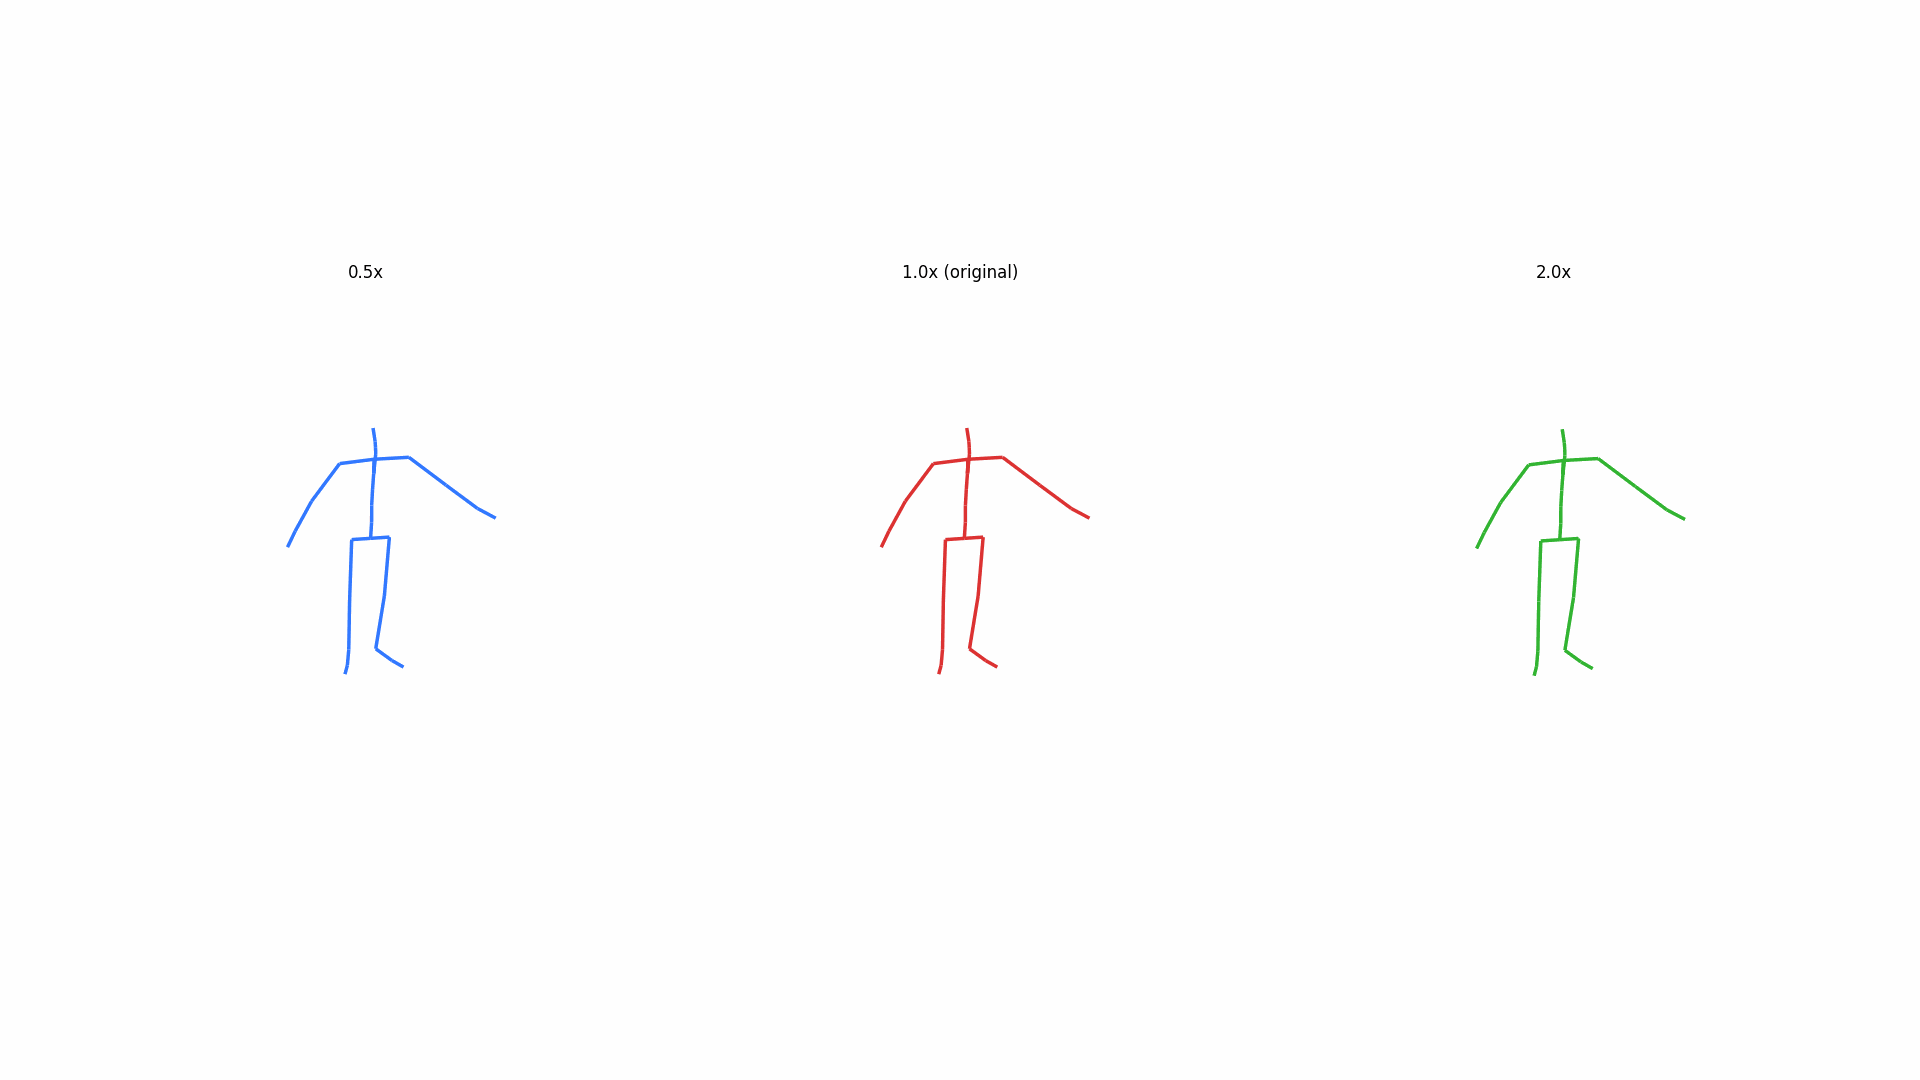

In [18]:
from IPython.display import Image

output_folder = Path('./output')
output_folder.mkdir(exist_ok=True)

gif_path = pybvh.bvhplot.render(
    [slower, bvh, faster],
    output_folder / 'speed_comparison.gif',
    labels=['0.5x', '1.0x (original)', '2.0x'],
    sync='pad',
    fps=15,
)
Image(str(gif_path))

The random variant samples uniformly from `factor_range` (default `(0.8, 1.2)` — moderate speed jitter).

In [19]:
rand_speed = bvh.random_perturb_speed(factor_range=(0.8, 1.2),
                                      rng=np.random.default_rng(42))
print(f'Original: {bvh.frame_count} frames')
print(f'Random speed: {rand_speed.frame_count} frames')

Original: 75 frames
Random speed: 67 frames


# Frame dropout

`drop_frames()` randomly selects a fraction of frames and **replaces** them with SLERP-interpolated values from their nearest kept neighbors. Root positions are linearly interpolated; joint rotations use quaternion SLERP.

The output has the **same number of frames** as the input — frames are *replaced*, not removed. What you lose is information, not samples. This simulates mocap systems with occasional dropped frames and also acts as a regularizer by forcing the model to tolerate noisy temporal data.

Kept frames are preserved exactly (bit-for-bit) — only the dropped frames are re-synthesized. The first and last frames are always kept (they have no valid neighbors to interpolate from on one side).

In [20]:
dropped = bvh.drop_frames(drop_rate=0.3, rng=np.random.default_rng(42))

print(f'Original frame count: {bvh.frame_count}')
print(f'After 30% dropout:    {dropped.frame_count}  (same count — gaps interpolated)')

# Endpoint preservation
print(f'\nFirst frame identical: {np.allclose(bvh.joint_angles[0], dropped.joint_angles[0])}')
print(f'Last  frame identical: {np.allclose(bvh.joint_angles[-1], dropped.joint_angles[-1])}')

Original frame count: 75
After 30% dropout:    75  (same count — gaps interpolated)

First frame identical: True
Last  frame identical: True


To see the replacement effect, plot one joint's angle curve over time. The original has natural motion detail; the dropped-and-interpolated version is smoother where frames were replaced (interpolation flattens fine motion).

In [21]:
# Plot a single joint channel over time, original vs. dropped
joint_idx = bvh.joint_index['Spine3']
channel = 0  # first Euler channel

dropped_heavy = bvh.drop_frames(drop_rate=0.5, rng=np.random.default_rng(0))

t = np.arange(bvh.frame_count) * bvh.frame_time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, bvh.joint_angles[:, joint_idx, channel],
        label='Original', linewidth=2, color='#1f77b4')
ax.plot(t, dropped_heavy.joint_angles[:, joint_idx, channel],
        label='After 50% dropout (SLERP-interpolated)', linewidth=1.5,
        color='#d62728', alpha=0.85)
ax.set_xlabel('Time (s)')
ax.set_ylabel(f'{bvh.joint_names[joint_idx]} angle (radians)')
ax.legend()
ax.set_title('Frame dropout replaces values in place; frame count unchanged')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2424241/4278997796.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Composing transforms

## The `inplace` parameter

All mutating transforms accept `inplace=False` (default, returns a new `Bvh`) or `inplace=True` (modifies `self` and returns `None`). The default is a new-object contract, which is why chaining works — each transform receives a fresh target and leaves the previous stage untouched.

Use `inplace=True` when you want to save memory on large clips and you're sure you don't need the original:

In [22]:
bvh_tmp = bvh.copy()
result = bvh_tmp.translate_root(offset=[10, 0, 0], inplace=True)

print(f'Return value: {result}')
print(f'bvh_tmp modified in place — root (frame 0): {bvh_tmp.root_pos[0]}')
print(f'Original bvh unchanged  — root (frame 0): {bvh.root_pos[0]}')

Return value: None
bvh_tmp modified in place — root (frame 0): [  9.1769 -10.8992  36.4219]
Original bvh unchanged  — root (frame 0): [ -0.8231 -10.8992  36.4219]


## Chaining

Because `inplace=False` is the default, transforms chain cleanly. Two styles:

In [23]:
rng = np.random.default_rng(42)

# Style A: method-chaining pipeline
aug_a = (bvh
         .mirror()
         .rotate_vertical(np.pi / 4)
         .add_noise(sigma=0.02, rng=rng)
         .perturb_speed(1.1))

# Style B: explicit reassignment (easier to debug, easier to branch)
aug_b = bvh.mirror()
aug_b = aug_b.rotate_vertical(np.pi / 4)
aug_b = aug_b.add_noise(sigma=0.02, rng=np.random.default_rng(42))
aug_b = aug_b.perturb_speed(1.1)

print(f'Style A result: {aug_a.frame_count} frames')
print(f'Style B result: {aug_b.frame_count} frames (same pipeline, same seed)')

Style A result: 68 frames
Style B result: 68 frames (same pipeline, same seed)


In [24]:
fig, axes = pybvh.bvhplot.frame([bvh, aug_a], frame=45,
                                 labels=['Original', 'Augmented'],
                                 camera=(120,20))
plt.show()

/tmp/ipykernel_2424241/2453164648.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Reproducibility

All stochastic transforms accept an `rng` parameter (a `numpy.random.Generator`). Seed it to make augmentations reproducible — essential for debugging, for unit tests, and for comparisons across experiments.

Two patterns:

- **Single RNG** (like Style A above): pass one `rng` to each call. Each call advances its internal state, so the sequence of random numbers depends on the order of transforms.
- **Fresh RNG per transform**: `rng=np.random.default_rng(seed)` per call — each transform is independently reproducible.

In [25]:
result_a = bvh.random_rotate_vertical(rng=np.random.default_rng(123))
result_b = bvh.random_rotate_vertical(rng=np.random.default_rng(123))

print(f'Same seed → same results: {np.allclose(result_a.root_pos, result_b.root_pos)}')

Same seed → same results: True


## Gotchas when composing

**Order matters for non-commutative transforms.** A few rules of thumb:

- **Apply deterministic preprocessing first.** `reorient_world_up`, `reorient_rest_up`, `reorient_rest_forward` should run before any stochastic augmentation so all augmentations operate in a normalized coordinate system.
- **Apply `add_noise` after `perturb_speed`, not before.** `perturb_speed` resamples via SLERP, which smooths away any noise injected beforehand — defeating the purpose.
- **Apply frame-count-changing transforms last** (`perturb_speed`, `drop_frames`). Transforms like `mirror` and `rotate_vertical` work frame-by-frame and are indifferent to frame count; keeping them upstream keeps the pipeline simple.
- **`mirror` + `rotate_vertical` commute** (both preserve lateral symmetry), so order doesn't matter for those two.

# Low-level array functions

For ML pipelines that work with pre-extracted NumPy arrays (not `Bvh` objects), `pybvh.transforms` exposes two NumPy-level primitives:

| Function | Input | Output | When to use |
|---|---|---|---|
| `rotate_angles_vertical` | `(F, J, 3)` angles + `(F, 3)` root + `up_idx`, `root_order` | rotated arrays | Tensor pipeline, no `Bvh` to wrap |
| `mirror_angles` | angles + root + LR index pairs + `lateral_idx` + `rot_channels` | mirrored arrays | Same |

These are the building blocks that the `Bvh` methods call internally. For batched, framework-integrated augmentation (quaternion or 6D space, PyTorch Datasets, etc.), see the companion library [pybvh-ml](https://github.com/VictorS-67/pybvh-ml).

# Summary

| Transform | Method | Family |
|---|---|---|
| L/R mirror | `bvh.mirror()` | Deterministic aug |
| Yaw rotation | `bvh.rotate_vertical(angle)` | Deterministic aug |
| Random yaw | `bvh.random_rotate_vertical(rng=...)` | Stochastic aug |
| Root translation | `bvh.translate_root(offset)` | Deterministic aug |
| Random translation | `bvh.random_translate_root(rng=...)` | Stochastic aug |
| Joint noise | `bvh.add_noise(sigma, rng=...)` | Stochastic aug |
| Speed change | `bvh.perturb_speed(factor)` | Deterministic aug |
| Random speed | `bvh.random_perturb_speed(rng=...)` | Stochastic aug |
| Frame dropout | `bvh.drop_frames(drop_rate, rng=...)` | Stochastic aug |
| Up-axis unify | `bvh.reorient_world_up(new_up)` | Preprocessing |
| Rest-pose up fix | `bvh.reorient_rest_up(new_up)` | Preprocessing |
| Rest-pose forward | `bvh.reorient_rest_forward(new_forward)` | Preprocessing |

All of the above are also callable as `pybvh.transforms.func(bvh, ...)`. All mutating transforms support `inplace=True` to modify the object in place. For full parameter reference, see the [Augmentation guide](https://victors-67.github.io/pybvh/guide/augmentation/) and the [World Up guide](https://victors-67.github.io/pybvh/guide/world-up/).

# What's next

- **Tutorial 6 — Motion Features**: velocities, accelerations, foot contacts, and feature-array export for ML.
- **Tutorial 7 — Batch Processing**: loading directories of BVH files, harmonization, and dataset preparation at scale.